# Tutorial 4: Fitting Mock Data with MAP Optimization

This tutorial demonstrates gradient-based MAP fitting — finding the single parameter set that best explains the data.

MAP (Maximum A Posteriori) minimizes the **information Hamiltonian**:

$$H(\xi \mid d) = \frac{1}{2} \chi^2 + \frac{1}{2} \xi^\top \xi$$

using Adam gradient descent ([optax](https://optax.readthedocs.io/)). It is extremely fast (seconds per galaxy) but gives only a **point estimate** — no error bars. For posteriors, see [Tutorial 5](05_inference_comparison.ipynb).

In [1]:
%matplotlib inline

In [2]:
import sys
sys.path.insert(0, "../src")

from diffsed.utils.devices import setup_jax
setup_jax()

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import time

plt.rcParams.update({
    "figure.dpi": 130, "font.size": 11,
    "axes.linewidth": 1.0,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "legend.framealpha": 0.9,
})

from diffsed.models.sps.dsps_wrapper import load_ssp_data
from diffsed.forward_model import ForwardModel, ModelConfig, generate_mock
from diffsed.inference.map_optimizer import fit_map
from diffsed.inference.common import PriorConfig, unbounded_to_physical
from diffsed.models.sfh.gp_sfh import gp_from_xi, compute_sqrt_power_drw
from diffsed.models.sfh.psd_models import drw_variance
from diffsed.models.sfh.mean_sfh import double_powerlaw
from diffsed.utils.grid import make_log_age_grid, grid_spacing, log_age_to_age_yr

# Load SSP templates
ssp_data = load_ssp_data("../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

# SDSS-like tophat filters (u, g, r, i, z)
filter_centers = [3551, 4686, 6166, 7480, 8932]
band_names = ["u", "g", "r", "i", "z"]
half_w = 100.0
filter_waves = [jnp.linspace(c - half_w, c + half_w, 50) for c in filter_centers]
filter_trans = [jnp.ones(50) for _ in filter_centers]

# GP grid
N_GRID = 256
log_age_grid = make_log_age_grid(N_GRID)
d_log_age = grid_spacing(log_age_grid)
age_yr = log_age_to_age_yr(log_age_grid)
age_gyr = age_yr / 1e9

print("Setup complete. SSP templates loaded.")

Setup complete. SSP templates loaded.


---
## 1. Generate Ground Truth

We generate a mock galaxy with **known parameters** as our ground truth. This gives us both
photometric (5 SDSS bands, SNR = 20) and spectroscopic (200 pixels, SNR = 10) mock data.
Because we know the true parameters we can quantify how well the optimizer recovers them.

In [3]:
# Model at z=0.1 with photometric filters
config = ModelConfig(n_grid=N_GRID, redshift=0.1)
model = ForwardModel(ssp_data, config, filter_waves, filter_trans)

# True parameters for a typical star-forming galaxy
true_params = {
    "xi": jax.random.normal(jax.random.PRNGKey(42), shape=(N_GRID,)),
    "sigma_ps": 1.5,       # GP PSD amplitude
    "tau_ps": 30e6,        # DRW damping timescale [yr]
    "alpha": 1.5,          # DPL falling index
    "beta": 0.8,           # DPL rising index
    "tau_sfh": 2e9,        # DPL turnover [yr]
    "sfr_norm": 5.0,       # SFR normalization [M$_{\odot}$/yr]
    "log_z": -0.5,         # log10(Z/Zsun)
    "tau_v1": 1.0,         # birth-cloud dust
    "tau_v2": 0.3,         # diffuse ISM dust
    "dust_n": -0.7,        # dust power-law slope
}

W0313 19:06:40.805769 2379929 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


In [4]:
# --- Photometric mock (5 bands, SNR=20) ---
mock_phot = generate_mock(model, true_params, key=jax.random.PRNGKey(0), snr=20.0)

# --- Spectroscopic mock (200 pixels, SNR=10) ---
wave_obs = jnp.linspace(4000, 9000, 200)  # observed-frame wavelength grid
spec_true = model.predict_spectrum(true_params, wave_obs)
spec_noise = spec_true / 10.0  # SNR=10 per pixel
spec_obs = spec_true + spec_noise * jax.random.normal(
    jax.random.PRNGKey(1), shape=spec_true.shape
)

# --- Reconstruct the true SFH for later comparison ---
def recover_sfh(params):
    """Compute the full SFH from a parameter dict."""
    sp = compute_sqrt_power_drw(
        N_GRID, float(d_log_age), params["sigma_ps"], params["tau_ps"]
    )
    gx = gp_from_xi(params["xi"], sp, N_GRID)
    k0 = drw_variance(params["sigma_ps"]) / 2.0
    sm = double_powerlaw(
        age_yr, params["alpha"], params["beta"],
        params["tau_sfh"], params["sfr_norm"]
    )
    return sm * jnp.exp(gx - k0)

sfr_true = recover_sfh(true_params)

print(f"Photometry : {len(band_names)} bands (ugriz), SNR = 20")
print(f"Spectroscopy: {len(wave_obs)} pixels, {float(wave_obs[0]):.0f}–{float(wave_obs[-1]):.0f} Å, SNR = 10")

Photometry : 5 bands (ugriz), SNR = 20
Spectroscopy: 200 pixels, 4000–9000 Å, SNR = 10


---
## 2. Photometry-Only Fitting

The loss function minimized by `fit_map` is the information Hamiltonian:

$$\mathcal{L} = \frac{1}{2} \sum_k \frac{(d_k - m_k)^2}{\sigma_k^2} \;+\; \frac{1}{2} \,\xi^\top \xi$$

The first term is the $\chi^2$ (data fidelity). The second term is the **standard-normal prior** on the GP latent vector $\xi$, which regularizes the SFH against unphysical oscillations.

Adam minimizes $\mathcal{L}$ using exact gradients from JAX autodiff — each iteration costs one forward-model evaluation. With 5 photometric bands constraining 11 physical parameters plus the 256-element latent vector, the problem is underdetermined; the prior on $\xi$ is what keeps it tractable.

In [5]:
result_phot = fit_map(
    model,
    mock_phot["flux_obs"],
    mock_phot["noise"],
    n_steps=1500,
    learning_rate=0.01,
    key=jax.random.PRNGKey(10),
    data_type="photometry",
)

print(f"\nPhotometry MAP fit complete")
print(f"  Wall time : {result_phot.wall_time_s:.1f} s")
print(f"  Final loss: {float(result_phot.loss_history[-1]):.2f}")
print(f"  Method    : {result_phot.method}")

  Step     0/1500: loss = 1024.9273


  Step   200/1500: loss = 1023.3976


  Step   400/1500: loss = 1022.6400


  Step   600/1500: loss = 1020.2345


  Step   800/1500: loss = 1013.1347


  Step  1000/1500: loss = 995.4550


  Step  1200/1500: loss = 959.2114


  Step  1400/1500: loss = 895.7883
  Step  1499/1500: loss = 851.3618
  MAP optimization complete in 3.2s

Photometry MAP fit complete
  Wall time : 3.2 s


  Final loss: 851.36
  Method    : MAP (Adam)


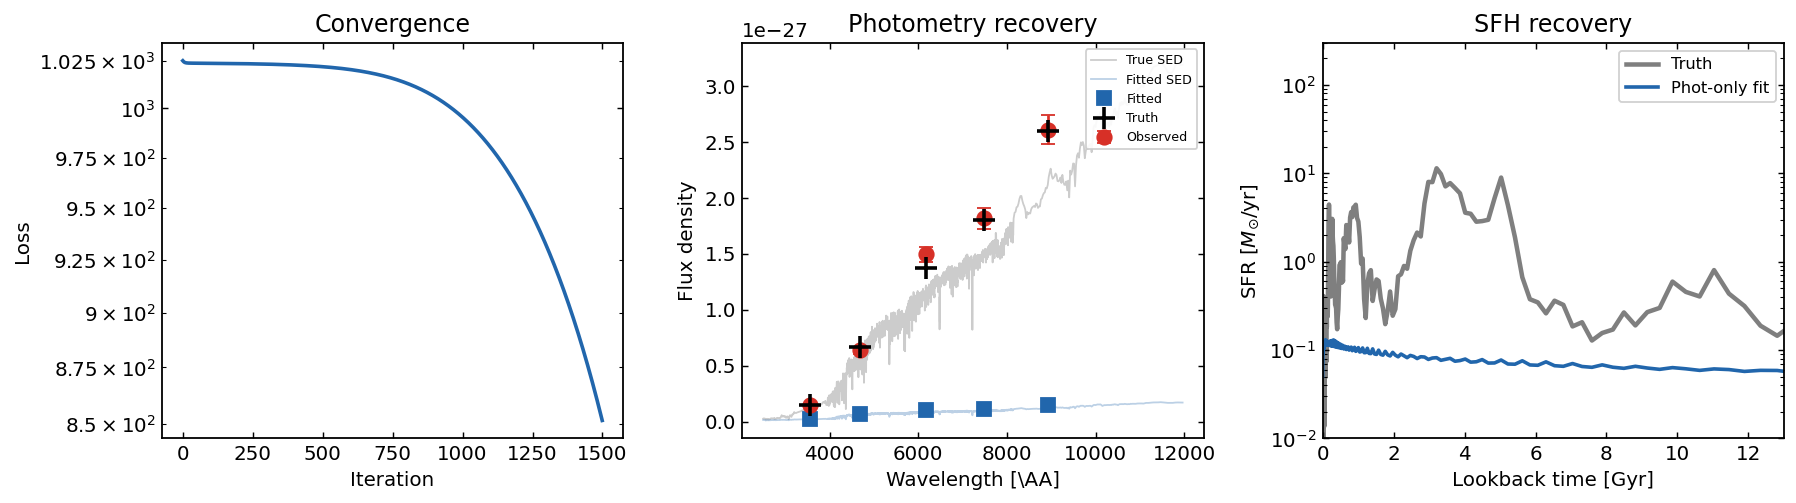

With only 5 photometric bands, the broad SFH shape is recovered
but fine time-structure (GP wiggles) is poorly constrained.


In [6]:
sfr_phot = recover_sfh(result_phot.params)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Panel 1: Convergence ---
ax = axes[0]
ax.plot(result_phot.loss_history, color="#2166ac", lw=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Convergence")
ax.set_yscale("log")

# --- Panel 2: Photometry recovery with SED background ---
ax = axes[1]
centers = jnp.array(filter_centers, dtype=float)

# Plot the full SED behind the photometric points
sed_fit = model(result_phot.params)
sed_true = model(true_params)
ssp_wave = ssp_data.ssp_wave
# Redshift the rest-frame wavelengths to observed frame
wave_rest_obs = ssp_wave * (1 + config.redshift)
# Rough flux scaling: normalize SED to match photometry magnitude
from diffsed.utils.cosmology import luminosity_distance
dl_cm = luminosity_distance(config.redshift)
sed_scale = 1.0 / (4 * jnp.pi * dl_cm**2 * (1 + config.redshift))

mask = (wave_rest_obs > 2500) & (wave_rest_obs < 12000)
ax.plot(wave_rest_obs[mask], sed_true[mask] * sed_scale,
        color="k", lw=1, alpha=0.2, label="True SED")
ax.plot(wave_rest_obs[mask], sed_fit[mask] * sed_scale,
        color="#2166ac", lw=1, alpha=0.3, label="Fitted SED")

# Photometric data and fits
flux_fit = model.predict_photometry(result_phot.params)
ax.errorbar(centers, mock_phot["flux_obs"], yerr=mock_phot["noise"],
            fmt="o", ms=8, capsize=4, color="#d73027", zorder=10, label="Observed")
ax.plot(centers, flux_fit, "s", ms=8, color="#2166ac", zorder=10, label="Fitted")
ax.plot(centers, mock_phot["flux_true"], "k+", ms=12, mew=2, zorder=11, label="Truth")
ax.set_xlabel(r"Wavelength [\AA]")
ax.set_ylabel("Flux density")
ax.set_title("Photometry recovery")
ax.legend(fontsize=7, loc="upper right")

# --- Panel 3: SFH recovery ---
ax = axes[2]
ax.plot(age_gyr, sfr_true, "k-", lw=2.5, alpha=0.5, label="Truth")
ax.plot(age_gyr, sfr_phot, color="#2166ac", lw=2, label="Phot-only fit")
ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel(r"SFR [$M_{\odot}$/yr]")
ax.set_title("SFH recovery")
ax.set_xlim(0, 13)
ax.set_yscale("log")
ax.set_ylim(0.01, 300)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("figures/04_phot_only_fit.png", dpi=150, bbox_inches="tight")
plt.show()

print("With only 5 photometric bands, the broad SFH shape is recovered")
print("but fine time-structure (GP wiggles) is poorly constrained.")

---
## 3. Spectroscopy-Only Fitting

Spectroscopy provides ~200 pixels versus 5 broadband fluxes, resolving features like the 4000 Å break
and Balmer absorption lines that **separately constrain age, dust, and metallicity**.

To fit spectroscopy, we set `model._wave_obs` to the observed wavelength grid and pass
`data_type="spectroscopy"` to `fit_map`. The loss function stays the same — only the
predicted data vector changes from 5 photometric fluxes to 200 spectral pixels.

In [7]:
# Set the observed wavelength grid on the model for spectroscopic fitting
model._wave_obs = wave_obs

result_spec = fit_map(
    model,
    spec_obs,
    spec_noise,
    n_steps=1500,
    learning_rate=0.01,
    key=jax.random.PRNGKey(20),
    data_type="spectroscopy",
)

print(f"\nSpectroscopy MAP fit complete")
print(f"  Wall time : {result_spec.wall_time_s:.1f} s")
print(f"  Final loss: {float(result_spec.loss_history[-1]):.2f}")
print(f"  Method    : {result_spec.method}")

  Step     0/1500: loss = 10013.5518


  Step   200/1500: loss = 10010.3332


  Step   400/1500: loss = 10004.2914


  Step   600/1500: loss = 9968.6399


  Step   800/1500: loss = 2998.6498


  Step  1000/1500: loss = 1560.6841


  Step  1200/1500: loss = 1196.1371


  Step  1400/1500: loss = 909.6669
  Step  1499/1500: loss = 784.0332
  MAP optimization complete in 3.1s

Spectroscopy MAP fit complete
  Wall time : 3.1 s
  Final loss: 784.03
  Method    : MAP (Adam)


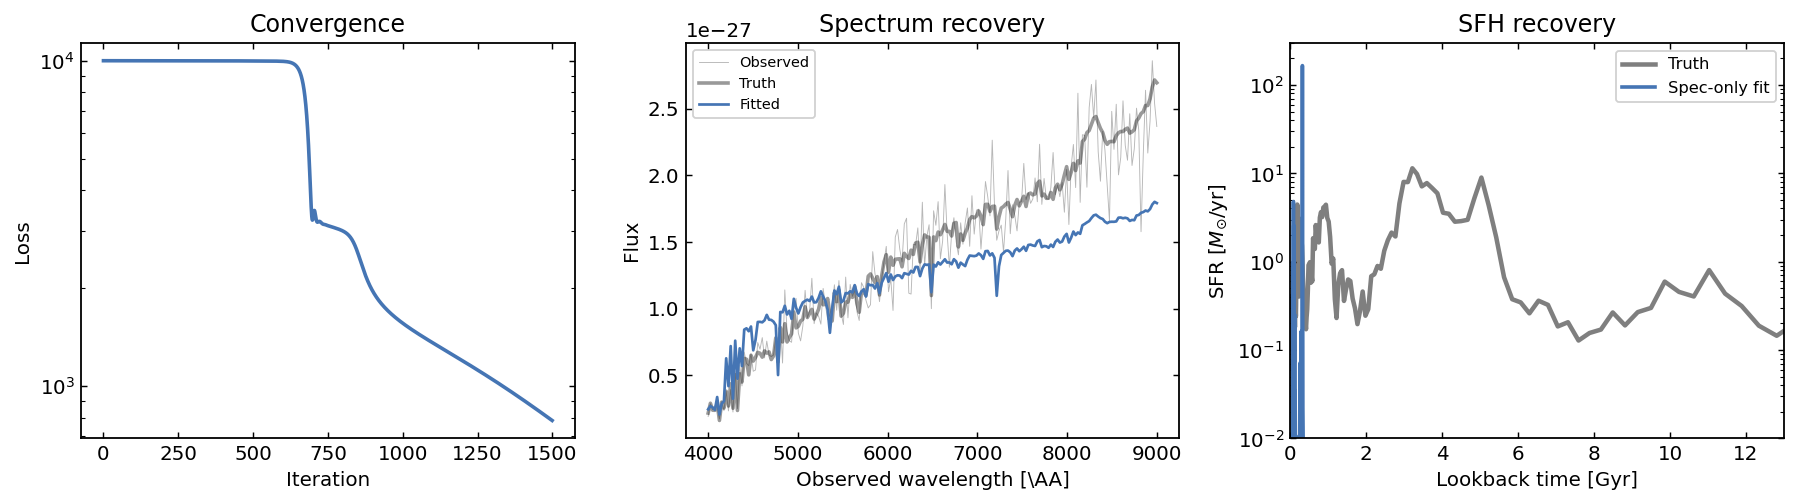

200 spectral pixels provide much tighter constraints than 5 bands.
Spectral features (breaks, lines) separately constrain age, dust, and Z.


In [8]:
sfr_spec = recover_sfh(result_spec.params)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Panel 1: Convergence ---
ax = axes[0]
ax.plot(result_spec.loss_history, color="#4575b4", lw=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Convergence")
ax.set_yscale("log")

# --- Panel 2: Spectrum recovery ---
ax = axes[1]
spec_fit = model.predict_spectrum(result_spec.params, wave_obs)
ax.plot(wave_obs, spec_obs, color="#999999", lw=0.5, alpha=0.7, label="Observed")
ax.plot(wave_obs, spec_true, "k-", lw=2, alpha=0.4, label="Truth")
ax.plot(wave_obs, spec_fit, color="#4575b4", lw=1.5, label="Fitted")
ax.set_xlabel(r"Observed wavelength [\AA]")
ax.set_ylabel("Flux")
ax.set_title("Spectrum recovery")
ax.legend(fontsize=8)

# --- Panel 3: SFH recovery ---
ax = axes[2]
ax.plot(age_gyr, sfr_true, "k-", lw=2.5, alpha=0.5, label="Truth")
ax.plot(age_gyr, sfr_spec, color="#4575b4", lw=2, label="Spec-only fit")
ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel(r"SFR [$M_{\odot}$/yr]")
ax.set_title("SFH recovery")
ax.set_xlim(0, 13)
ax.set_yscale("log")
ax.set_ylim(0.01, 300)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("figures/04_spec_only_fit.png", dpi=150, bbox_inches="tight")
plt.show()

print("200 spectral pixels provide much tighter constraints than 5 bands.")
print("Spectral features (breaks, lines) separately constrain age, dust, and Z.")

---
## 4. SNR Dependence

How much signal-to-noise do you need? We fit the same galaxy at **SNR = 5, 10, 20, 50**
using photometry and compare parameter recovery. This is a critical question for survey design:
deeper data costs more telescope time, but the gain in parameter precision may saturate.

In [9]:
snr_values = [5, 10, 20, 50]
snr_results = {}
snr_colors = {5: "#d73027", 10: "#fc8d59", 20: "#91bfdb", 50: "#4575b4"}

for snr in snr_values:
    mock_i = generate_mock(
        model, true_params, key=jax.random.PRNGKey(snr), snr=float(snr)
    )
    res = fit_map(
        model, mock_i["flux_obs"], mock_i["noise"],
        key=jax.random.PRNGKey(snr + 100),
        n_steps=1500,
        learning_rate=0.01,
        data_type="photometry",
        verbose=False,
    )
    snr_results[snr] = res
    print(f"  SNR={snr:2d}  final_loss={float(res.loss_history[-1]):8.2f}  "
          f"wall_time={res.wall_time_s:.1f}s")

  SNR= 5  final_loss=   50.92  wall_time=3.1s


  SNR=10  final_loss=  201.36  wall_time=3.1s


  SNR=20  final_loss=  798.13  wall_time=3.2s


  SNR=50  final_loss=  979.33  wall_time=3.1s


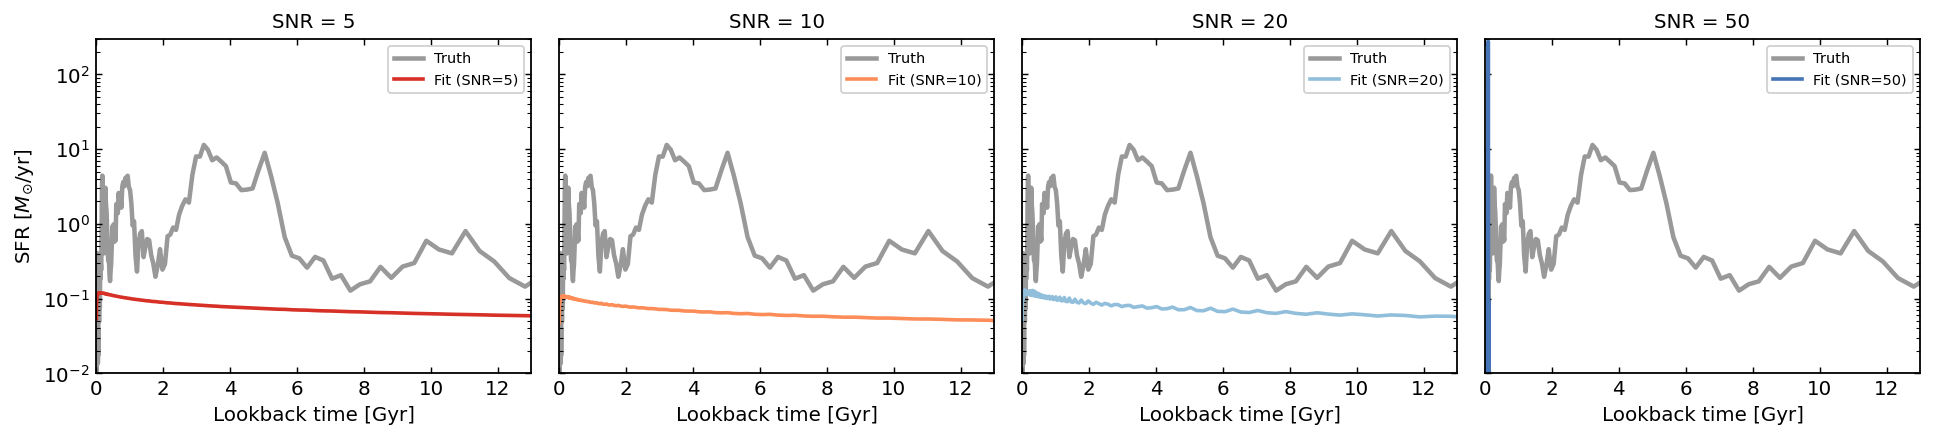

   Parameter        True       SNR=5      SNR=10      SNR=20      SNR=50
------------------------------------------------------------------------
    sigma_ps       1.500       0.403       0.413       0.454       1.871
       alpha       1.500       0.276       0.282       0.278       1.088
        beta       0.800       0.308       0.311       0.307       0.662
     tau_sfh    2.00e+09    1.00e+08    1.00e+08    1.00e+08    1.00e+08
    sfr_norm       5.000       0.248       0.222       0.239       0.054
       log_z      -0.500      -0.869      -0.825      -0.868      -0.826
      tau_v1       1.000       0.183       0.200       0.197       1.450
      tau_v2       0.300       0.160       0.154       0.162       1.213
      dust_n      -0.700      -0.122      -0.127      -0.129      -0.850

Higher SNR -> better SFH recovery, but gains flatten past SNR ~ 20.
At SNR=5, only the broad shape is constrained.


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharey=True)

for ax, snr in zip(axes, snr_values):
    sfr_fit = recover_sfh(snr_results[snr].params)
    ax.plot(age_gyr, sfr_true, "k-", lw=2.5, alpha=0.4, label="Truth")
    ax.plot(age_gyr, sfr_fit, lw=2, color=snr_colors[snr], label=f"Fit (SNR={snr})")
    ax.set_xlabel("Lookback time [Gyr]")
    ax.set_title(f"SNR = {snr}", fontsize=11)
    ax.set_xlim(0, 13)
    ax.set_yscale("log")
    ax.set_ylim(0.01, 300)
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"SFR [$M_{\odot}$/yr]")

plt.tight_layout()
plt.savefig("figures/04_snr_recovery.png", dpi=150, bbox_inches="tight")
plt.show()

# Parameter recovery table
scalar_params = ["sigma_ps", "alpha", "beta", "tau_sfh", "sfr_norm",
                 "log_z", "tau_v1", "tau_v2", "dust_n"]

header = f"{'Parameter':>12s}  {'True':>10s}"
for snr in snr_values:
    header += f"  {'SNR='+str(snr):>10s}"
print(header)
print("-" * len(header))

for p in scalar_params:
    true_val = float(true_params[p])
    if abs(true_val) < 1e4:
        row = f"{p:>12s}  {true_val:10.3f}"
    else:
        row = f"{p:>12s}  {true_val:10.2e}"
    for snr in snr_values:
        fit_val = float(snr_results[snr].params[p])
        if abs(fit_val) < 1e4:
            row += f"  {fit_val:10.3f}"
        else:
            row += f"  {fit_val:10.2e}"
    print(row)

print("\nHigher SNR -> better SFH recovery, but gains flatten past SNR ~ 20.")
print("At SNR=5, only the broad shape is constrained.")

---
## 5. Parallel Fitting with `jax.vmap`

For catalog-scale fitting, we need to evaluate the forward model on many galaxies
simultaneously. JAX's `vmap` (vectorized map) executes the forward model across a
batch of galaxies in parallel on GPU — this is the key to scaling from single galaxies
to thousands.

Below we generate 10 mock galaxies with different parameters, then compare the wall
time of a **sequential Python loop** vs. a **single vmapped call**.

In [11]:
rng = np.random.default_rng(123)
n_batch = 10

# Draw random parameters for the batch
batch_params_list = []
for i in range(n_batch):
    p = {
        "xi": jax.random.normal(jax.random.PRNGKey(i * 7 + 200), shape=(N_GRID,)),
        "sigma_ps": rng.uniform(0.5, 2.5),
        "tau_ps": 10 ** rng.uniform(6.5, 8.0),
        "alpha": rng.uniform(0.5, 2.5),
        "beta": rng.uniform(0.3, 1.5),
        "tau_sfh": 10 ** rng.uniform(9.0, 10.0),
        "sfr_norm": 10 ** rng.uniform(0.0, 1.2),
        "log_z": rng.uniform(-1.5, -0.2),
        "tau_v1": rng.uniform(0.1, 2.0),
        "tau_v2": rng.uniform(0.05, 0.8),
        "dust_n": rng.uniform(-1.2, -0.4),
    }
    batch_params_list.append(p)

# Stack into a batched dict for vmap
batch_params = jax.tree.map(lambda *xs: jnp.stack(xs), *batch_params_list)

# --- Sequential loop ---
_ = model.predict_photometry(batch_params_list[0])  # warm-up JIT
t0 = time.time()
seq_results = [model.predict_photometry(p) for p in batch_params_list]
seq_results = jnp.stack(seq_results)
jax.block_until_ready(seq_results)
t_seq = time.time() - t0

# --- Vectorized (vmap) ---
vmap_predict = jax.vmap(model.predict_photometry)
_ = vmap_predict(batch_params)  # warm-up JIT
t0 = time.time()
vmap_results = vmap_predict(batch_params)
jax.block_until_ready(vmap_results)
t_vmap = time.time() - t0

print(f"Batch of {n_batch} galaxies:")
print(f"  Sequential loop : {t_seq*1000:.1f} ms")
print(f"  jax.vmap        : {t_vmap*1000:.1f} ms")
print(f"  Speedup         : {t_seq / t_vmap:.1f}x")
print(f"\nResults match: {jnp.allclose(seq_results, vmap_results, atol=1e-5)}")

Batch of 10 galaxies:
  Sequential loop : 32.8 ms
  jax.vmap        : 19.9 ms
  Speedup         : 1.7x

Results match: True


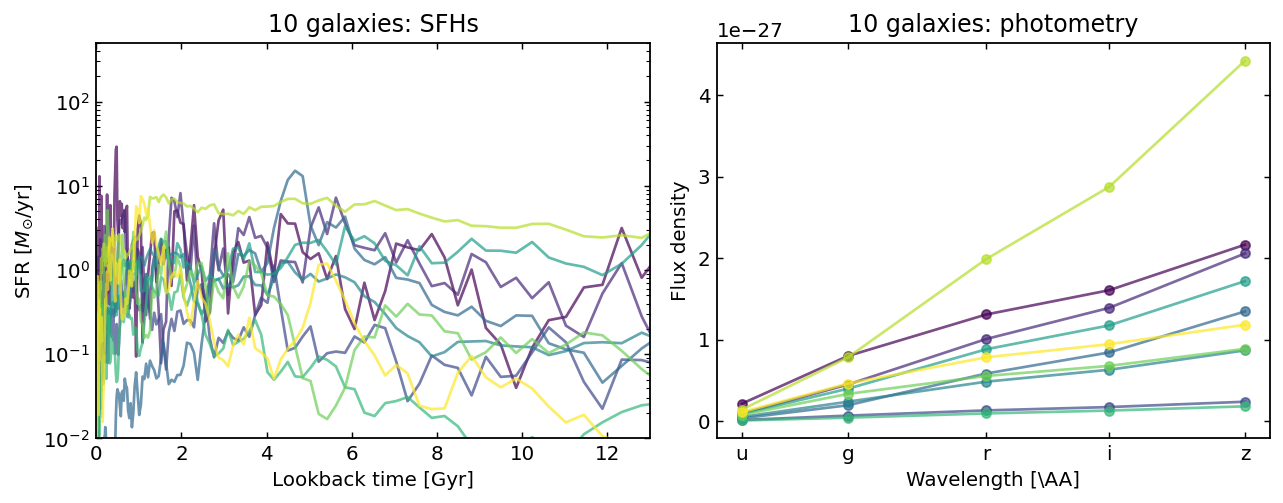

vmap parallelizes the forward model across 10 galaxies.
On GPU, this scales to thousands with near-constant wall time.


In [12]:
# Visualize the batch: SFHs and photometry
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cmap = plt.cm.viridis
colors_batch = [cmap(i / (n_batch - 1)) for i in range(n_batch)]

for i in range(n_batch):
    sfr_i = recover_sfh(batch_params_list[i])
    axes[0].plot(age_gyr, sfr_i, lw=1.5, color=colors_batch[i], alpha=0.7)

axes[0].set_xlabel("Lookback time [Gyr]")
axes[0].set_ylabel(r"SFR [$M_{\odot}$/yr]")
axes[0].set_title(f"{n_batch} galaxies: SFHs")
axes[0].set_xlim(0, 13)
axes[0].set_yscale("log")
axes[0].set_ylim(0.01, 500)

centers_arr = jnp.array(filter_centers, dtype=float)
for i in range(n_batch):
    axes[1].plot(centers_arr, vmap_results[i], "o-", ms=5, lw=1.5,
                color=colors_batch[i], alpha=0.7)

axes[1].set_xlabel(r"Wavelength [\AA]")
axes[1].set_ylabel("Flux density")
axes[1].set_title(f"{n_batch} galaxies: photometry")
axes[1].set_xticks(centers_arr)
axes[1].set_xticklabels(band_names)

plt.tight_layout()
plt.savefig("figures/04_vmap_batch.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"vmap parallelizes the forward model across {n_batch} galaxies.")
print("On GPU, this scales to thousands with near-constant wall time.")

---
## 6. Parameter Recovery Summary

How do photometry-only and spectroscopy-only fits compare? Below we show the true
values alongside the MAP estimates from each data type.

In [13]:
scalar_params = ["sigma_ps", "tau_ps", "alpha", "beta", "tau_sfh", "sfr_norm",
                 "log_z", "tau_v1", "tau_v2", "dust_n"]

def fmt_val(v):
    v = float(v)
    if abs(v) >= 1e6:
        return f"{v:.2e}"
    return f"{v:.3f}"

header = f"{'Parameter':>12s}  {'True':>12s}  {'Phot fit':>12s}  {'Spec fit':>12s}"
print(header)
print("=" * len(header))

for p in scalar_params:
    true_v = fmt_val(true_params[p])
    phot_v = fmt_val(result_phot.params[p])
    spec_v = fmt_val(result_spec.params[p])
    print(f"{p:>12s}  {true_v:>12s}  {phot_v:>12s}  {spec_v:>12s}")

print(f"\n{'Wall time':>12s}  {'':>12s}  {result_phot.wall_time_s:11.1f}s  {result_spec.wall_time_s:11.1f}s")

print("\nMAP provides point estimates only — no uncertainties.")
print("For posteriors and error bars, see Tutorial 5 (NUTS, geoVI).")

   Parameter          True      Phot fit      Spec fit
    sigma_ps         1.500         0.469         1.807
      tau_ps      3.00e+07      1.00e+06      1.00e+06
       alpha         1.500         0.275         0.752
        beta         0.800         0.310         0.752
     tau_sfh      2.00e+09      1.00e+08      1.00e+08
    sfr_norm         5.000         0.237         0.044
       log_z        -0.500        -0.853        -0.849
      tau_v1         1.000         0.198         1.031
      tau_v2         0.300         0.156         1.046
      dust_n        -0.700        -0.130        -0.793

   Wall time                        3.2s          3.1s

MAP provides point estimates only — no uncertainties.
For posteriors and error bars, see Tutorial 5 (NUTS, geoVI).


---
## Summary

### What we covered

| Topic | Key takeaway |
|-------|-------------|
| **MAP fitting** | Minimizes $H = \frac{1}{2}\chi^2 + \frac{1}{2}\xi^\top\xi$ via Adam — seconds per galaxy |
| **Photometry** | 5 bands constrain broad SED shape; SFH details are under-determined |
| **Spectroscopy** | 200 pixels resolve spectral features, breaking age-dust-Z degeneracies |
| **SNR dependence** | Recovery improves with SNR but gains flatten past SNR ~ 20 for broadband |
| **`jax.vmap`** | Parallelizes the forward model across galaxies for catalog-scale fitting |

### Limitations of MAP

- **No error bars**: MAP gives a single best-fit, not a posterior distribution
- **Local optima**: Adam can get stuck in local minima, especially with noisy data
- **Degeneracies are hidden**: age-dust-metallicity degeneracies are not visible without posterior samples

### Next steps

- **[Tutorial 5](05_inference_comparison.ipynb)**: Full posterior inference with NUTS and geoVI — error bars, correlations, and degeneracy maps
- **MAP as initialization**: The MAP solution from `fit_map` can seed MCMC chains for faster convergence